In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')

# Estilo global 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

# Paleta de colores por grupo diagnóstico (CN / MCI / AD)
DX_PALETTE = {'CN': '#2ecc71', 'MCI': '#f39c12', 'AD': '#e74c3c'}
DX_ORDER   = ['CN', 'MCI', 'AD']

DATA_DIR = Path('data')

In [2]:
df_raw = pd.read_csv(DATA_DIR / 'TADPOLE_D1_D2.csv', low_memory=False)

print(f'Shape raw: {df_raw.shape}')
print(f'Número de features: {df_raw.shape[1]}')
print(f'Número de pacientes únicos: {df_raw["RID"].nunique()}')
print('\nTipos de columnas:\n', df_raw.dtypes.value_counts())

Shape raw: (12741, 1907)
Número de features: 1907
Número de pacientes únicos: 1737

Tipos de columnas:
 str        1827
float64      72
int64         8
Name: count, dtype: int64


#  1 - CALIDAD DE DATOS

###  1.1 - SELECCIÓN DE LOS REGISTROS

Antes de comenzar con el EDA, es importante seleccionar los datos con los que vamos a trabajar. Es importante entender de donde viene cada registro para saber si nos resulta útil o no.

El diccionario nos indica que hay dos campos, **D1** y **D2**, que indican de que base de datos procede el registro. Estos valores indican el split, y son los siguientes:
| D1  | D2  | Significado                                                                                                   |
|-----|-----|---------------------------------------------------------------------------------------------------------------|
| 1   | 0   | Solo en entrenamiento — visitas históricas de pacientes que no llegaron al periodo de predicción              |
| 1   | 1   | En ambos — pacientes que tienen historial (D1) y también visitas en la ventana de predicción (D2)             |
| 0   | 1   | Solo en predicción — visitas sin historial previo en D1                                                       |
| 0   | 0   | Ninguno — filas marginales/administrativas, no se usan                                                        |


Una vez visto esto, haremos el EDA sobre todos los registros, pero eliminándo aquellos que tienen D1 = 0 y D2 = 0. El resto lo trataremos igual.

In [3]:
# Eliminamos las filas donde D1 = 0 y D2 = 0
df_raw = df_raw[(df_raw['D1'] != 0) | (df_raw['D2'] != 0)]

print(f'Shape después de eliminar filas: {df_raw.shape}')
print(f'Número de features: {df_raw.shape[1]}')
print(f'Número de pacientes únicos: {df_raw["RID"].nunique()}')

Shape después de eliminar filas: (12685, 1907)
Número de features: 1907
Número de pacientes únicos: 1681


###  1.2 - ESTUDIO DE VALORES NULOS

In [4]:
# Calculamos nulos
nulls = df_raw.isnull().sum()

# Creamos DataFrame resumen
missing = pd.DataFrame({
    'Número de Nulos': nulls,
    'Porcentaje de Nulos': (nulls / len(df_raw)) * 100
}).sort_values('Porcentaje de Nulos', ascending=False)

# Mostramos estadísticas
print(f"Total columnas: {len(missing)}")
print(f"Sin ningún nulo: {(missing['Porcentaje de Nulos'] == 0).sum()}")
print(f"Con > 20% nulos: {(missing['Porcentaje de Nulos'] > 20).sum()}")
print(f"Con > 50% nulos: {(missing['Porcentaje de Nulos'] > 50).sum()}")
print(f"Con > 80% nulos: {(missing['Porcentaje de Nulos'] > 80).sum()}")
print(f"Con > 95% nulos: {(missing['Porcentaje de Nulos'] > 95).sum()}")

print("\nTop 20 columnas con más nulos:")

# Mostramos DataFrame
display(missing.head(20))

Total columnas: 1907
Sin ningún nulo: 1452
Con > 20% nulos: 61
Con > 50% nulos: 35
Con > 80% nulos: 3
Con > 95% nulos: 2

Top 20 columnas con más nulos:


,Número de Nulos,Porcentaje de Nulos
PIB_bl,12540,98.856918
PIB,12463,98.249901
AV45,10581,83.413480
FDG,9360,73.787939
EcogSPOrgan,7845,61.844698
EcogPtOrgan,7795,61.450532
EcogSPDivatt,7751,61.103666
MOCA,7739,61.009066
EcogPtVisspat,7723,60.882933
EcogPtDivatt,7721,60.867166


In [5]:
# Eliminamos las columnas con >95% nulos (PIB y PIB_bl)
cols_drop_nulls = ['PIB', 'PIB_bl']
df_raw = df_raw.drop(columns=[c for c in cols_drop_nulls if c in df_raw.columns])

print(f"Columnas eliminadas: {cols_drop_nulls}")
print(f"Shape resultante: {df_raw.shape}")

Columnas eliminadas: ['PIB', 'PIB_bl']
Shape resultante: (12685, 1905)


###  1.3 - SELECCIÓN DE VARIABLES

In [6]:
COLS_ID = ['RID', 'PTID', 'VISCODE', 'EXAMDATE', 'D1', 'D2']
COLS_TARGET = ['DX', 'DX_bl', 'DXCHANGE']
COLS_PROTO = ['SITE', 'COLPROT', 'ORIGPROT']
COLS_DEMO = ['AGE', 'PTGENDER', 'PTEDUCAT', 'APOE4', 'PTETHCAT', 'PTRACCAT', 'PTMARRY']
COLS_COG = ['CDRSB', 'ADAS11', 'ADAS13', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 'RAVLT_perc_forgetting', 'FAQ', 'MOCA']
COLS_COG_BL = [f'{c}_bl' for c in COLS_COG]

COLS_MRI = ['Hippocampus', 'Entorhinal', 'Fusiform', 'MidTemp', 'Ventricles', 'WholeBrain', 'ICV']
COLS_MRI_BL = [f'{c}_bl' for c in COLS_MRI]

COLS_PET = ['FDG', 'AV45']
COLS_PET_BL = ['FDG_bl', 'AV45_bl']
COLS_CSF = ['ABETA_UPENNBIOMK9_04_19_17', 'TAU_UPENNBIOMK9_04_19_17', 'PTAU_UPENNBIOMK9_04_19_17']


ALL_COLS = (COLS_ID + COLS_TARGET + COLS_PROTO + COLS_DEMO + COLS_COG + COLS_COG_BL + COLS_MRI + COLS_MRI_BL +
            COLS_PET + COLS_PET_BL + COLS_CSF)

df = df_raw[[c for c in ALL_COLS if c in df_raw.columns]].copy()

print(f"Columnas originales:{df_raw.shape[1]}")
print(f"Columnas seleccionadas: {df.shape[1]}")
print(f"Filas: {df.shape[0]:,}")
print(f"Pacientes únicos:{df['RID'].nunique():,}")
print("Columnas por grupo:")
print(f"Identificadores:  {len(COLS_ID)}")
print(f"Target: {len(COLS_TARGET)}")
print(f"Protocolo: {len(COLS_PROTO)}")
print(f"Demográficos: {len(COLS_DEMO)}")
print(f"Cognitivos: {len(COLS_COG) + len(COLS_COG_BL)}")
print(f"MRI: {len(COLS_MRI) + len(COLS_MRI_BL)}")
print(f"PET: {len(COLS_PET) + len(COLS_PET_BL)}")
print(f"CSF: {len(COLS_CSF)}")

Columnas originales:1905
Columnas seleccionadas: 60
Filas: 12,685
Pacientes únicos:1,681
Columnas por grupo:
Identificadores:  6
Target: 3
Protocolo: 3
Demográficos: 7
Cognitivos: 20
MRI: 14
PET: 4
CSF: 3


####  1.3.1 - ANÁLISIS DE VALORES NULOS SOBRE LAS VARIABLES SELECCIONADAS

In [7]:
# Definimos a qué grupo pertenece cada variable
grupos = {
    'Demográfico': COLS_DEMO,
    'Cognitivo': COLS_COG,
    'Cognitivo_bl': COLS_COG_BL,
    'MRI': COLS_MRI,
    'MRI_bl': COLS_MRI_BL,
    'PET': COLS_PET,
    'PET_bl': COLS_PET_BL,
    'CSF': COLS_CSF,
}

# Calculamos nulos
nulls = df.isnull().sum()

# Creamos DataFrame
missing = pd.DataFrame({
    'Número de Nulos': nulls,
    'Porcentaje de Nulos': (nulls / len(df)) * 100
}).sort_values('Porcentaje de Nulos', ascending=False)

# Función para asignar grupo
def get_grupo(col):
    for g, cols in grupos.items():
        if col in cols:
            return g
    return 'ID/Target/Protocolo'

# Añadimos columna de grupo
missing['grupo'] = missing.index.map(get_grupo)

# Mostramos solo las variables con nulos
missing_filtered = missing[missing['Número de Nulos'] > 0][
    ['grupo', 'Número de Nulos', 'Porcentaje de Nulos']
]

display(missing_filtered)
print(missing_filtered.shape)

,grupo,Número de Nulos,Porcentaje de Nulos
AV45,PET,10581,83.413480
FDG,PET,9360,73.787939
MOCA,Cognitivo,7739,61.009066
MOCA_bl,Cognitivo_bl,6975,54.986204
AV45_bl,PET_bl,6949,54.781238
Fusiform,MRI,6258,49.333859
Entorhinal,MRI,6258,49.333859
MidTemp,MRI,6258,49.333859
Hippocampus,MRI,5925,46.708711
Ventricles,MRI,5290,41.702799


(42, 3)


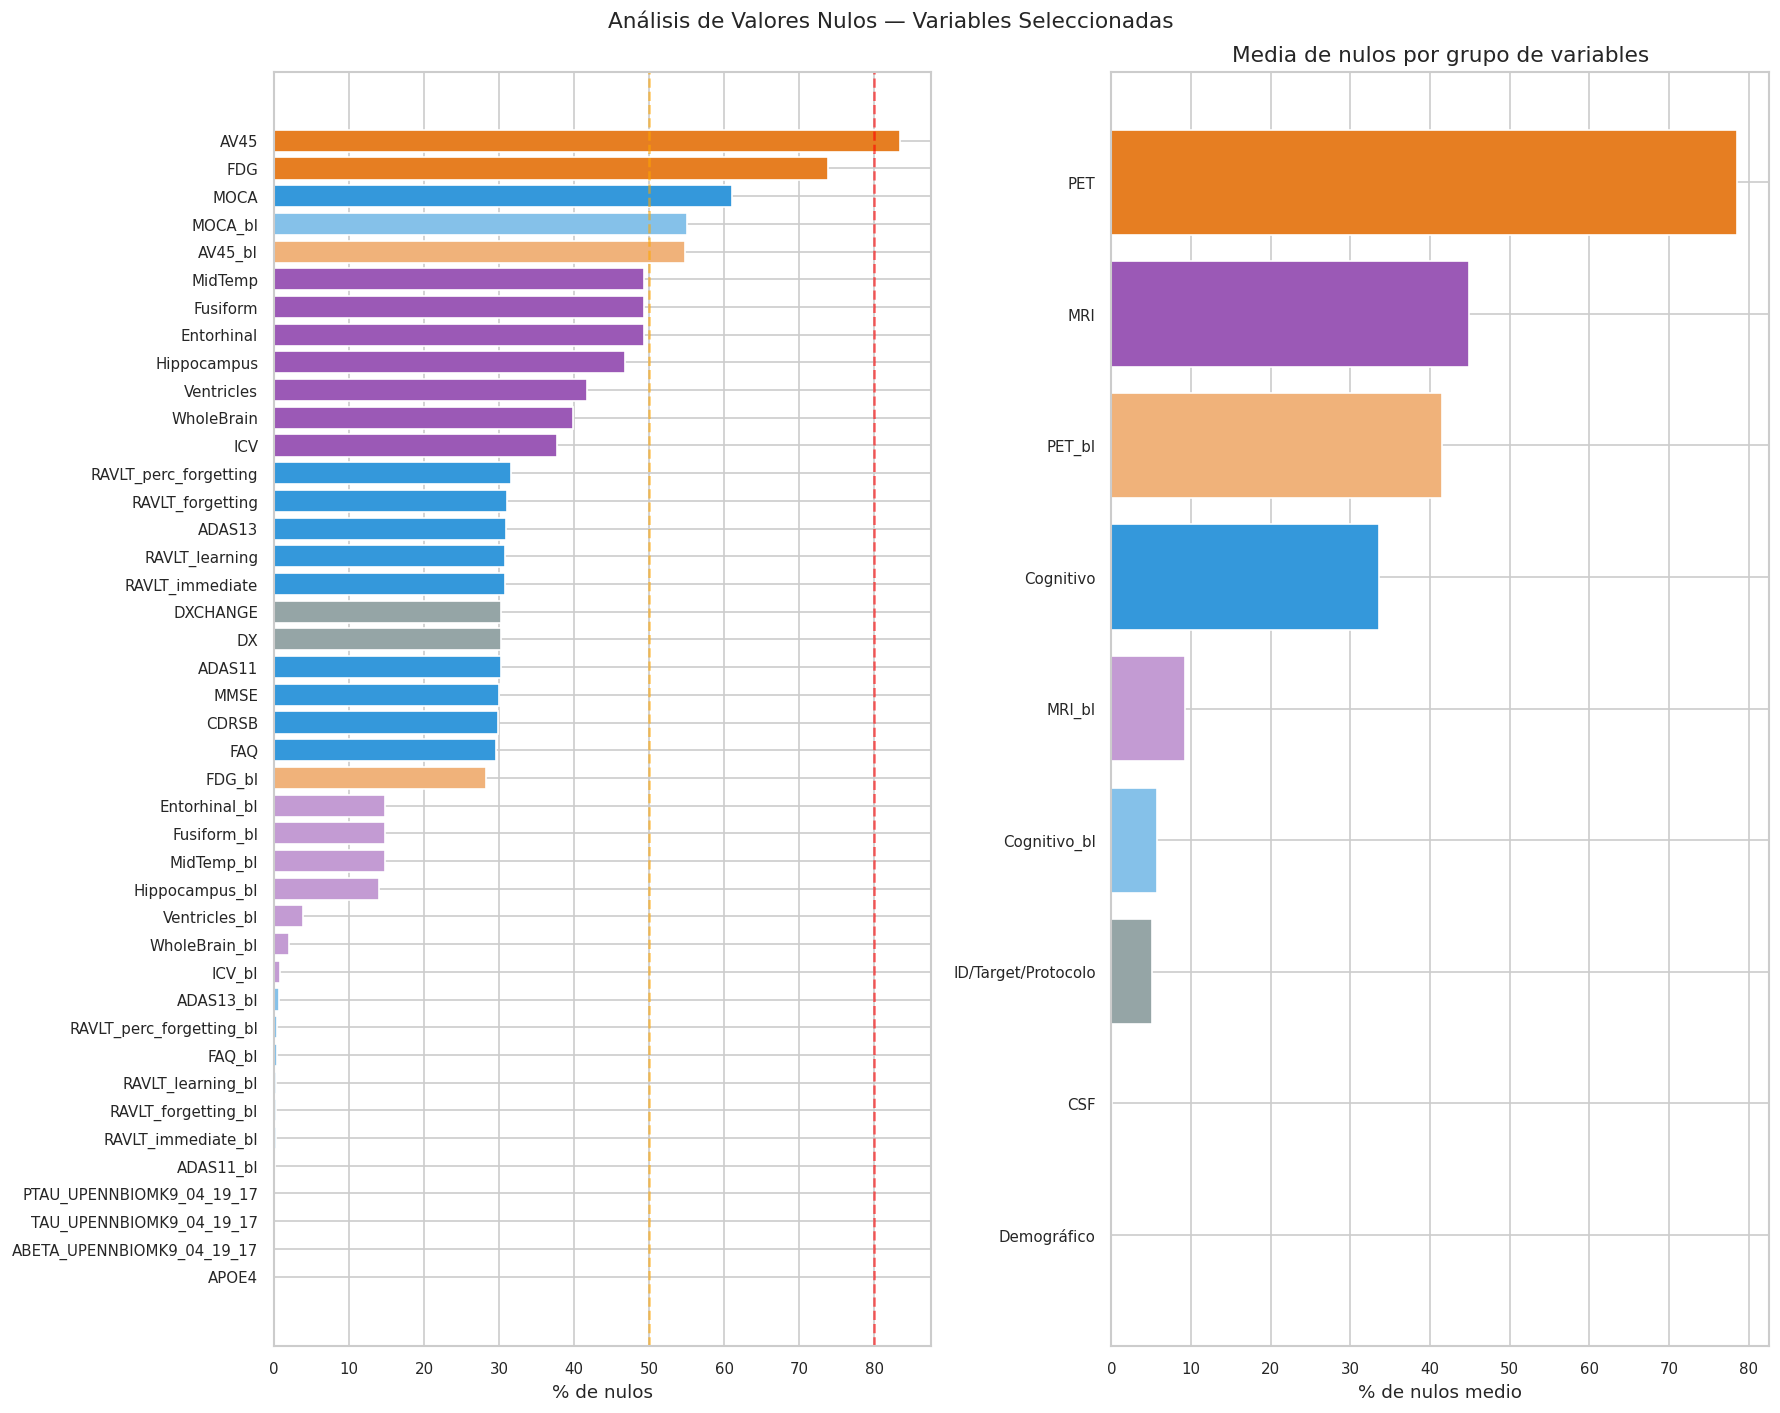

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 12))

# Barplot por variable
ax = axes[0]
data_plot = missing[missing['Número de Nulos'] > 0].sort_values('Porcentaje de Nulos', ascending=True)
colores = {'Demográfico':'#2ecc71','Cognitivo':'#3498db','Cognitivo_bl':'#85c1e9',
           'MRI':'#9b59b6','MRI_bl':'#c39bd3','PET':'#e67e22','PET_bl':'#f0b27a',
           'CSF':'#e74c3c','ID/Target/Protocolo':'#95a5a6'}
bars = ax.barh(data_plot.index, data_plot['Porcentaje de Nulos'],
               color=[colores.get(g,'#95a5a6') for g in data_plot['grupo']])
ax.axvline(80, color='red', linestyle='--', alpha=0.6, label='80%')
ax.axvline(50, color='orange', linestyle='--', alpha=0.6, label='50%')
ax.set_xlabel('% de nulos')

# Barplot por grupo (media)
ax = axes[1]
resumen_plot = missing.groupby('grupo')['Porcentaje de Nulos'].mean().sort_values(ascending=True)
ax.barh(resumen_plot.index, resumen_plot.values,
        color=[colores.get(g,'#95a5a6') for g in resumen_plot.index])
ax.set_xlabel('% de nulos medio')
ax.set_title('Media de nulos por grupo de variables')

plt.suptitle('Análisis de Valores Nulos — Variables Seleccionadas', fontsize=13)
plt.tight_layout()
plt.show()

####  1.3.2 - ANÁLISIS DE VALORES DUPLICADOS SOBRE LAS VARIABLES SELECCIONADAS

In [9]:
n_dup_exactos = df.duplicated().sum()
n_dup_visita  = df.duplicated(subset=['RID', 'EXAMDATE']).sum()
n_dup_viscode = df.duplicated(subset=['RID', 'VISCODE']).sum()

print(f"Filas duplicadas exactas: {n_dup_exactos}")
print(f"Duplicados por (RID + EXAMDATE): {n_dup_visita}")
print(f"Duplicados por (RID + VISCODE): {n_dup_viscode}")

Filas duplicadas exactas: 0
Duplicados por (RID + EXAMDATE): 3
Duplicados por (RID + VISCODE): 0


In [10]:
dup_mask = df.duplicated(subset=['RID', 'EXAMDATE'], keep=False)
print(df[dup_mask][['RID', 'VISCODE', 'EXAMDATE', 'DX', 'CDRSB']].to_string())

        RID VISCODE    EXAMDATE   DX  CDRSB
5576   1195     m48  2011-02-15   NL    0.0
8376   1088     m78  2013-01-23  NaN    NaN
8586   1195     m42  2011-02-15  NaN    NaN
11633  1088     m72  2013-01-23  NaN   12.0
12214  4960     m36  2015-11-16   NL    0.5
12215  4960     m48  2015-11-16   NL    0.0


Para cada par de visitas duplicadas (RID + EXAMDATE), ordenamos el dataframe por número de nulos en las variables clínicas (de menos a más), de forma que la fila más completa quede primera. Después aplicamos drop_duplicates conservando solo la primera ocurrencia de cada par.

In [11]:
cols_clinicas = COLS_COG + COLS_MRI + COLS_PET + COLS_CSF

df['_n_nulos'] = df[cols_clinicas].isnull().sum(axis=1)
df = (df
      .sort_values('_n_nulos')
      .drop_duplicates(subset=['RID', 'EXAMDATE'])
      .drop(columns='_n_nulos')
      .reset_index(drop=True))

print(f"Shape tras eliminar duplicados: {df.shape}")
print(f"Pacientes únicos: {df['RID'].nunique():,}")

Shape tras eliminar duplicados: (12682, 60)
Pacientes únicos: 1,681


####  1.3.3 - ANÁLISIS DE CONSISTENCIA TEMPORAL SOBRE LAS VARIABLES SELECCIONADAS

In [12]:
df['EXAMDATE'] = pd.to_datetime(df['EXAMDATE'])
df = df.sort_values(['RID', 'EXAMDATE']).reset_index(drop=True)

print(f"Rango de fechas: {df['EXAMDATE'].min().date()}  -->  {df['EXAMDATE'].max().date()}")

Rango de fechas: 2005-09-07  -->  2017-05-05


In [13]:
df['_days_diff'] = df.groupby('RID')['EXAMDATE'].diff().dt.days

n_negativos = (df['_days_diff'] < 0).sum()
n_cero = (df['_days_diff'] == 0).sum()

print(f"Visitas con intervalo negativo: {n_negativos}")
print(f"Visitas con intervalo = 0 días: {n_cero}")

Visitas con intervalo negativo: 0
Visitas con intervalo = 0 días: 0


Estadísticos del intervalo entre visitas (días):
count    11001.0
mean       207.4
std        120.5
min          3.0
25%        168.0
50%        183.0
75%        202.0
max       1763.0

Visitas a ~6m  (150–210 días): 6,774
Visitas a ~12m (330–390 días): 760
Visitas a ~24m (690–750 días): 93


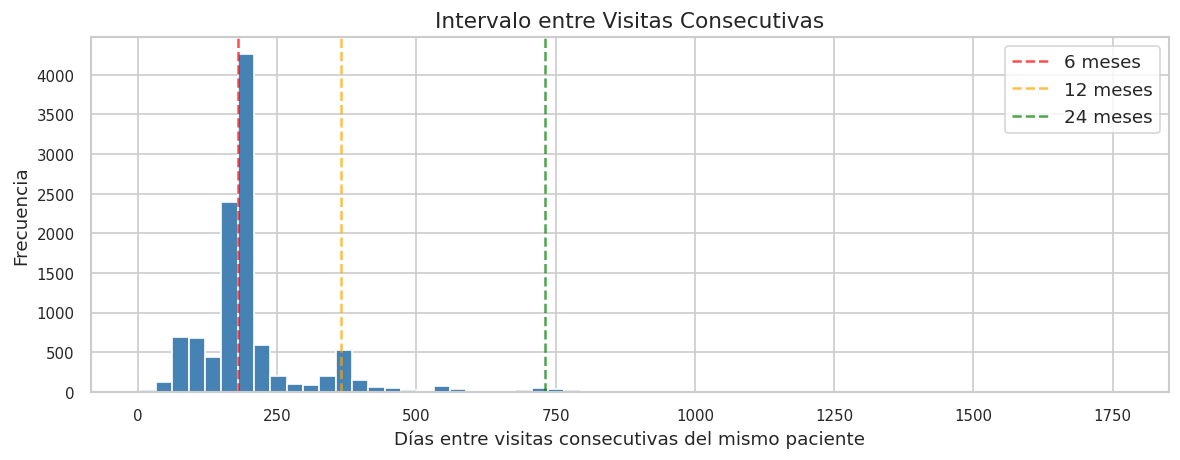

In [14]:
intervals = df['_days_diff'].dropna()

print("Estadísticos del intervalo entre visitas (días):")
print(intervals.describe().round(1).to_string())
print()
print(f"Visitas a ~6m  (150–210 días): {((intervals>=150)&(intervals<=210)).sum():,}")
print(f"Visitas a ~12m (330–390 días): {((intervals>=330)&(intervals<=390)).sum():,}")
print(f"Visitas a ~24m (690–750 días): {((intervals>=690)&(intervals<=750)).sum():,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(intervals, bins=60, color='steelblue', edgecolor='white')
ax.axvline(180, color='red',    linestyle='--', alpha=0.7, label='6 meses')
ax.axvline(365, color='orange', linestyle='--', alpha=0.7, label='12 meses')
ax.axvline(730, color='green',  linestyle='--', alpha=0.7, label='24 meses')
ax.set_xlabel('Días entre visitas consecutivas del mismo paciente')
ax.set_ylabel('Frecuencia')
ax.set_title('Intervalo entre Visitas Consecutivas')
ax.legend()
plt.tight_layout()
plt.show()

df = df.drop(columns='_days_diff')

El análisis de consistencia temporal no ha detectado ninguna anomalía en la ordenación de las visitas: **0 intervalos negativos y 0 intervalos nulos**, lo que confirma que todas las secuencias por paciente están correctamente ordenadas cronológicamente.

Respecto a la cadencia de visitas, el histograma muestra un **pico dominante en torno a los 180 días (~6 meses)**, que corresponde a la frecuencia de seguimiento estándar del protocolo ADNI. Se observa un segundo pico menor alrededor de los 365 días (12 meses) para pacientes con seguimiento anual, así como visitas ligeramente adelantadas o retrasadas respecto a las ventanas nominales, comportamiento habitual en estudiosclínicos longitudinales.

Destaca la presencia de una **cola derecha con intervalos superiores a los 500 días**, que puede alcanzar hasta ~1.800 días. Estos casos corresponden a pacientes que abandonaron el estudio y se reincorporaron en una fase posterior del protocolo ADNI (ADNI1 → ADNI2 → ADNI3), o bien a pacientes que perdieron visitas consecutivas.

Este patrón de **intervalos irregulares** tiene implicaciones directas en el diseño del modelo, es decir, una arquitectura RNN/LSTM estándar asume pasos de tiempo equiespaciados, por lo que será necesario incorporar el delta temporal entre visitas como variable adicional, o bien considerar arquitecturas que traten el tiempo de forma explícita como GRU-D.

####  1.3.4 - ANÁLISIS DE VALORES ANÓMALOS SOBRE LAS VARIABLES SELECCIONADAS

In [15]:
df.describe()

,RID,EXAMDATE,D1,D2,DXCHANGE,SITE,AGE,PTEDUCAT,APOE4,CDRSB,...,Entorhinal_bl,Fusiform_bl,MidTemp_bl,Ventricles_bl,WholeBrain_bl,ICV_bl,FDG,AV45,FDG_bl,AV45_bl
count,12682.000000,12682,12682.000000,12682.000000,8841.000000,12682.000000,12682.000000,12682.000000,12681.000000,8906.000000,...,10802.000000,10802.00000,10802.000000,12198.000000,1.243800e+04,1.259000e+04,3325.000000,2104.000000,9103.000000,5735.000000
mean,2240.325974,2011-04-11 05:24:03.747043,0.998896,0.603848,2.097387,73.253115,73.811820,15.989986,0.537891,2.172019,...,3552.340215,17425.35873,19674.179596,39063.413592,1.025221e+06,1.537656e+06,1.208038,1.194769,1.246752,1.202141
min,2.000000,2005-09-07 00:00:00,0.000000,0.000000,1.000000,2.000000,55.000000,4.000000,0.000000,0.000000,...,1426.000000,8991.00000,9375.000000,5650.000000,6.693640e+05,1.100690e+06,0.636804,0.835796,0.697264,0.838537
25%,618.000000,2008-07-28 06:00:00,1.000000,0.000000,1.000000,22.000000,69.600000,14.000000,0.000000,0.000000,...,3035.000000,15684.00000,17736.000000,23506.000000,9.465720e+05,1.422670e+06,1.109700,1.010085,1.157830,1.019440
50%,1280.000000,2011-12-19 00:00:00,1.000000,1.000000,2.000000,41.000000,73.800000,16.000000,0.000000,1.000000,...,3580.000000,17352.00000,19601.500000,33816.000000,1.022380e+06,1.524570e+06,1.219490,1.114200,1.253490,1.125370
75%,4327.750000,2013-06-21 00:00:00,1.000000,1.000000,3.000000,116.000000,78.700000,18.000000,1.000000,3.000000,...,4104.000000,19115.00000,21677.000000,49345.000000,1.098540e+06,1.644780e+06,1.314320,1.362005,1.338750,1.374980
max,5296.000000,2017-05-05 00:00:00,1.000000,1.000000,8.000000,941.000000,91.400000,20.000000,2.000000,18.000000,...,5896.000000,29950.00000,32189.000000,145115.000000,1.486040e+06,2.110290e+06,1.753320,2.669210,1.707170,2.025560
std,1855.365694,NaN,0.033208,0.489116,1.088252,107.616863,6.962964,2.827141,0.656083,2.814905,...,772.111861,2654.80869,2969.614047,21872.991147,1.093825e+05,1.633657e+05,0.160884,0.227430,0.145606,0.221979


#  2 - DISTRIBUCIONES

###  2.1 - VARIABLE OBJETIVO

Primero tenemos que observar los distinct values de la variable objetivo. Y después aplicaremos un mapeo común para tener 3 clases.

In [16]:
print("Valores únicos de DX:")
print(df['DX'].value_counts(dropna=False).to_string())
print()
print("Valores únicos de DX_bl:")
print(df['DX_bl'].value_counts(dropna=False).to_string())

Valores únicos de DX:
DX
MCI                3909
NaN                3829
NL                 2657
Dementia           1715
MCI to Dementia     372
NL to MCI           108
MCI to NL            77
Dementia to MCI      12
NL to Dementia        3

Valores únicos de DX_bl:
DX_bl
LMCI    4625
CN      3812
EMCI    2310
AD      1549
SMC      386


In [17]:
dx_map = {
    'NL': 'CN',
    'NL to MCI': 'MCI',
    'NL to Dementia': 'AD',
    'MCI': 'MCI',
    'MCI to NL': 'CN',
    'MCI to Dementia': 'AD',
    'Dementia': 'AD',
    'Dementia to MCI': 'MCI',
}

dxbl_map = {
    'CN': 'CN',
    'SMC': 'CN',
    'EMCI': 'MCI',
    'LMCI': 'MCI',
    'AD': 'AD',
}

df['DX3'] = df['DX'].map(dx_map)
df['DX3_bl'] = df['DX_bl'].map(dxbl_map)

print("DX3 — diagnóstico simplificado por visita:")
print(df['DX3'].value_counts(dropna=False).to_string())
print()
print("DX3_bl — diagnóstico basal simplificado:")
print(df['DX3_bl'].value_counts(dropna=False).to_string())

DX3 — diagnóstico simplificado por visita:
DX3
MCI    4029
NaN    3829
CN     2734
AD     2090

DX3_bl — diagnóstico basal simplificado:
DX3_bl
MCI    6935
CN     4198
AD     1549


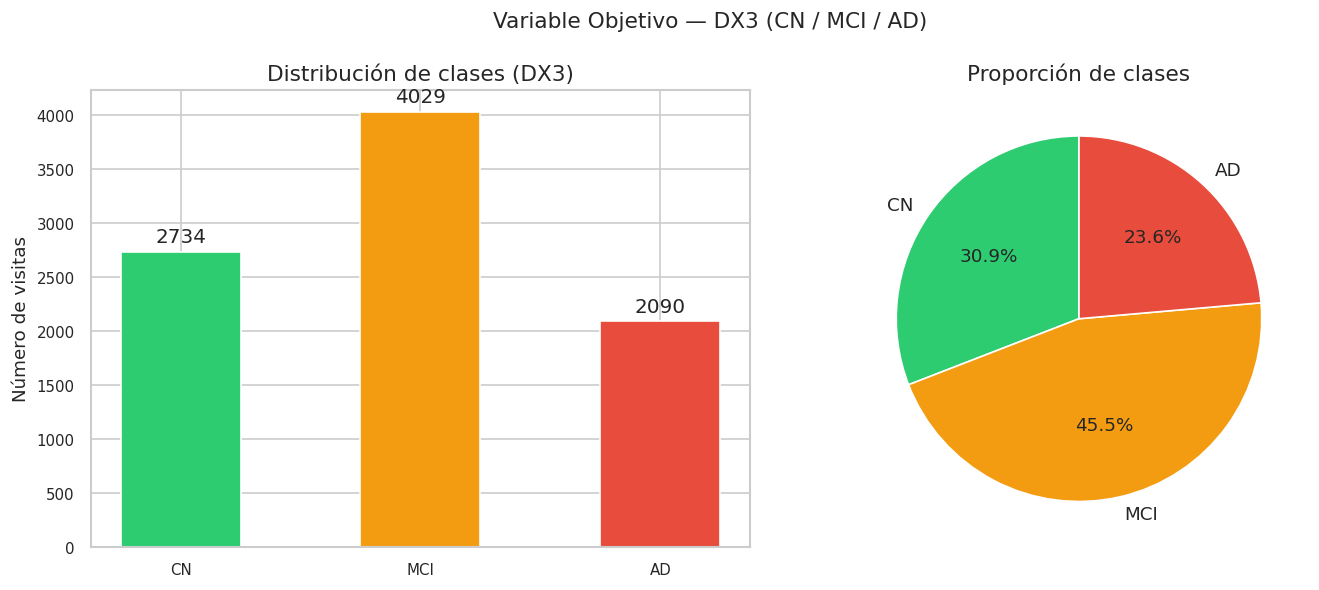

In [18]:
DX_PALETTE = {'CN': '#2ecc71', 'MCI': '#f39c12', 'AD': '#e74c3c'}
DX_ORDER   = ['CN', 'MCI', 'AD']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
ax = axes[0]
counts = df['DX3'].value_counts().reindex(DX_ORDER).dropna()
bars = ax.bar(counts.index, counts.values,
              color=[DX_PALETTE[k] for k in counts.index],
              edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_ylabel('Número de visitas')
ax.set_title('Distribución de clases (DX3)')

# Pie
ax = axes[1]
counts.plot(kind='pie', ax=ax,
            colors=[DX_PALETTE[k] for k in counts.index],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
ax.set_title('Proporción de clases')
ax.set_ylabel('')

plt.suptitle('Variable Objetivo — DX3 (CN / MCI / AD)', fontsize=13)
plt.tight_layout()
plt.show()

La distribución de clases muestra un **desbalanceo moderado**.

MCI es la clase mayoritaria (45.5%), seguida de CN (30.9%) y AD como clase minoritaria (23.6%). Este desbalanceo puede llevar al modelo a sesgar sus predicciones hacia MCI, infradiagnosticando los casos AD — clínicamente los más críticos de detectar. 

Para corregirlo hay que aplicar **class_weight='balanced'** en el entrenamiento, que penaliza más los errores en clases minoritarias, y/o técnicas de sobremuestreo como **SMOTE** aplicadas únicamente sobre el conjunto de entrenamiento.

###  2.2 - ESTADÍSTICOS DESCRIPTIVOS POR GRUPO

In [19]:
# Convertir CSF a numérico
for col in COLS_CSF:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

grupos_vars = {
    'Cognitivos': COLS_COG,
    'MRI': COLS_MRI,
    'PET': COLS_PET,
    'CSF': COLS_CSF,
}

df_dx = df[df['DX3'].isin(DX_ORDER)]

for grupo, cols in grupos_vars.items():
    cols_exist = [c for c in cols if c in df.columns]
    tabla = (df_dx
             .groupby('DX3')[cols_exist]
             .median(numeric_only=True)
             .reindex(DX_ORDER)
             .round(2)
             .T)
    print(f"\n{'='*60}")
    print(f"  {grupo} — Mediana por grupo diagnóstico")
    print(f"{'='*60}")
    print(tabla.to_string())


  Cognitivos — Mediana por grupo diagnóstico
DX3                      CN    MCI     AD
CDRSB                   0.0   1.50    5.0
ADAS11                  5.0   9.00   20.0
ADAS13                  8.0  15.33   31.0
MMSE                   29.0  28.00   22.0
RAVLT_immediate        44.0  32.00   21.0
RAVLT_learning          6.0   4.00    2.0
RAVLT_forgetting        3.0   5.00    4.0
RAVLT_perc_forgetting  30.0  66.67  100.0
FAQ                     0.0   2.00   16.0
MOCA                   26.0  24.00   17.0

  MRI — Mediana por grupo diagnóstico
DX3                 CN        MCI         AD
Hippocampus     7308.5     6752.0     5476.0
Entorhinal      3758.0     3518.0     2655.0
Fusiform       17587.0    17414.5    14926.0
MidTemp        19796.0    19483.5    16591.5
Ventricles     32299.0    37052.5    49138.0
WholeBrain   1019900.0  1021420.0   952158.5
ICV          1506810.0  1537350.0  1527250.0

  PET — Mediana por grupo diagnóstico
DX3     CN   MCI    AD
FDG   1.29  1.23  1.05
AV45  1.

Los estadísticos descriptivos muestran un **gradiente claro y consistente CN --> MCI --> AD** en todas las modalidades. 

En cognitivos, variables como RAVLT_perc_forgetting y FAQ discriminan especialmente bien entre grupos. 

En MRI se observa la atrofia progresiva esperada: el Hippocampus pierde un 25% de volumen de CN a AD, mientras que los Ventricles aumentan (expansión compensatoria por pérdida de tejido). Los biomarcadores siguen el patrón A/T/N del Alzheimer: la ABETA en CSF **disminuye** de CN a AD (se acumula en placas y desaparece del líquido), mientras que TAU, PTAU y AV45 **aumentan** (daño neuronal y carga amiloide). Estos patrones confirman que las variables seleccionadas son clínicamente relevantes y discriminativas para el modelo.

###  2.3 - DISTRIBUCIONES VISUALES

####  2.3.1 - TESTS COGNITIVOS

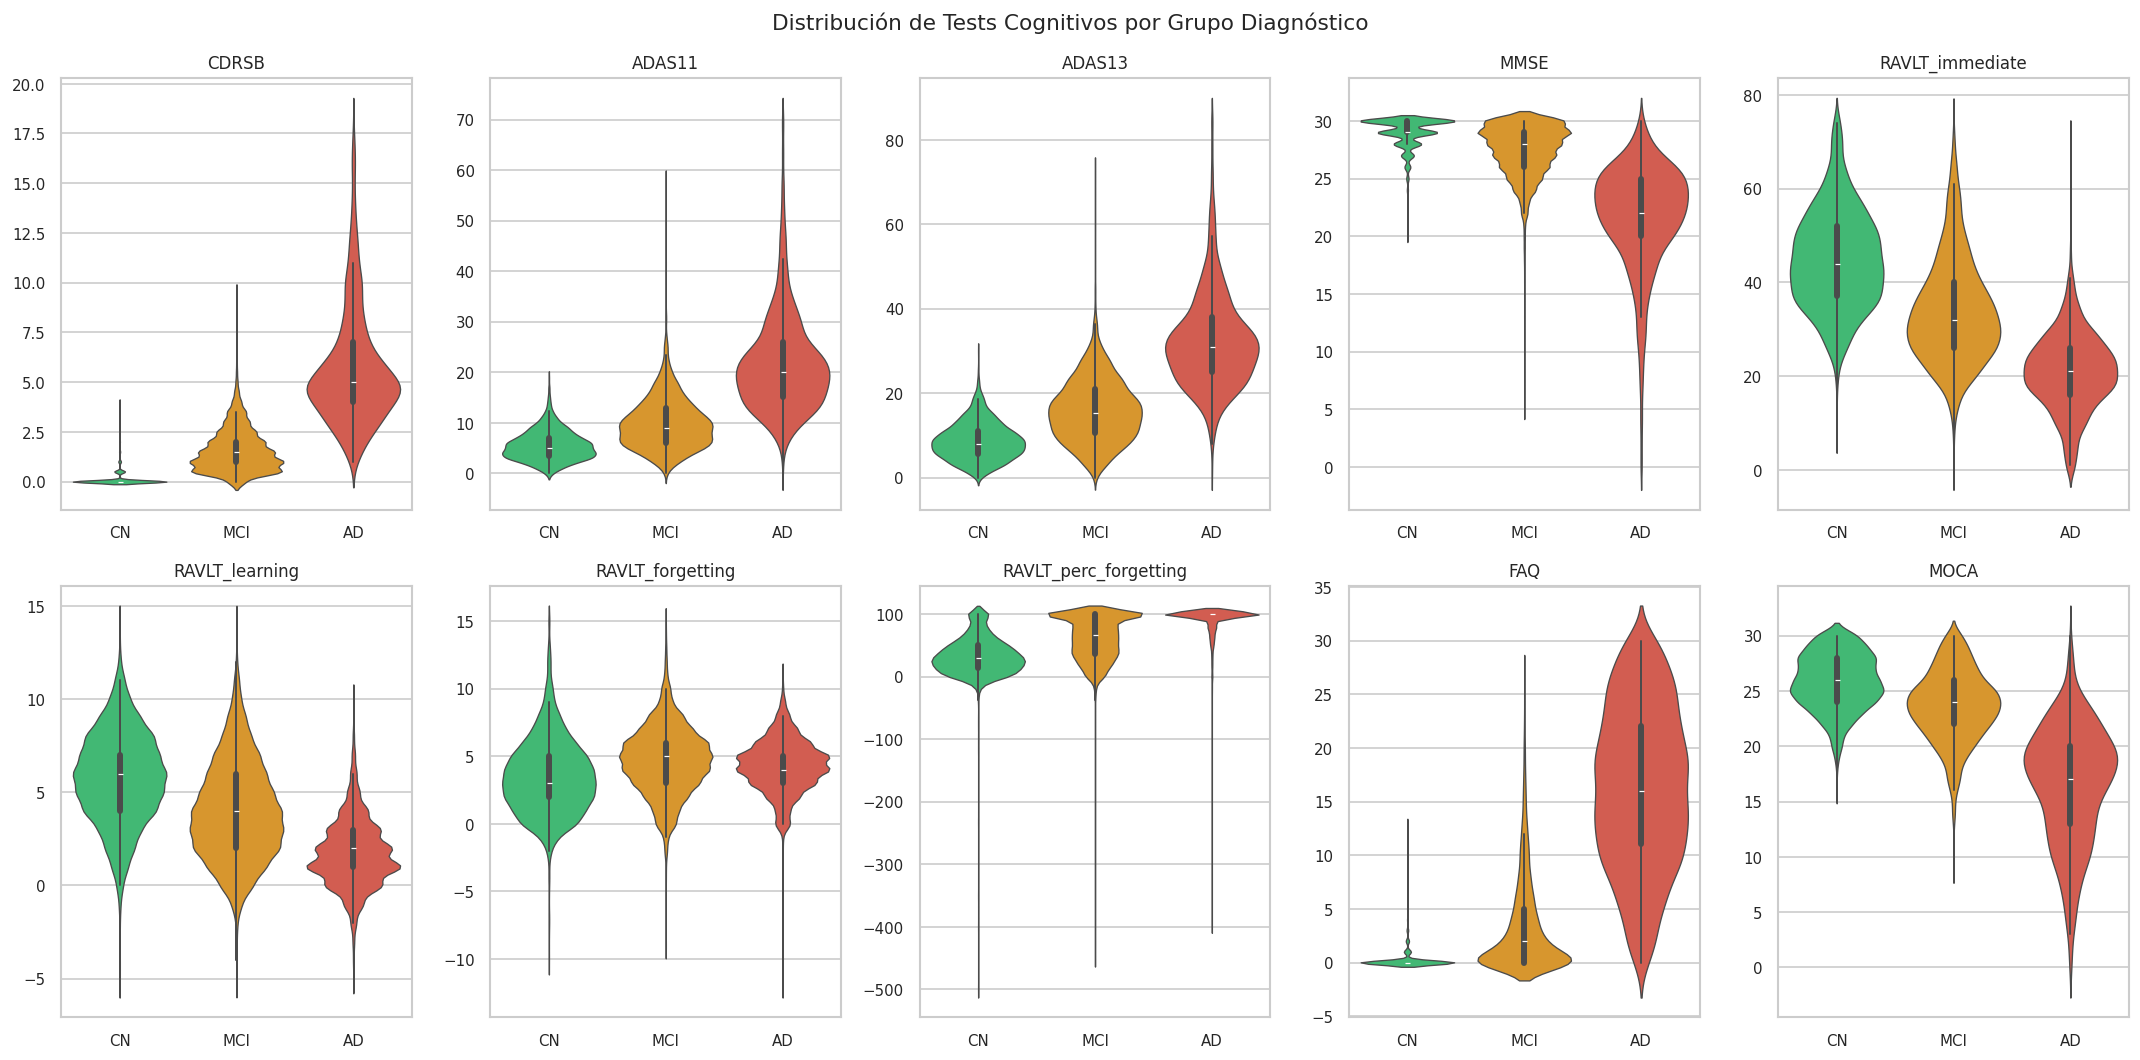

In [20]:
df_dx = df[df['DX3'].isin(DX_ORDER)].copy()

fig, axes = plt.subplots(2, 5, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(COLS_COG):
    ax = axes[i]
    sns.violinplot(data=df_dx, x='DX3', y=col, order=DX_ORDER,
                   palette=DX_PALETTE, ax=ax, inner='box',
                   linewidth=0.8, density_norm='width')
    ax.set_xlabel('')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')

plt.suptitle('Distribución de Tests Cognitivos por Grupo Diagnóstico', fontsize=13)
plt.tight_layout()
plt.show()

Los violin plots confirman un **gradiente diagnóstico claro CN --> MCI --> AD** en prácticamente todos los tests cognitivos. 

Variables como **FAQ** (0 → 2 → 16) y **CDRSB** (concentrado en 0 para CN, amplio en AD) son las que mejor separan los grupos, siendo especialmente útiles para el modelo. 

**MMSE** y **RAVLT_immediate** muestran el patrón inverso esperado: los CN se concentran en los valores más altos (techo del test) y los AD se dispersan hacia valores bajos.

####  2.3.2 - VOLÚMENES MRI

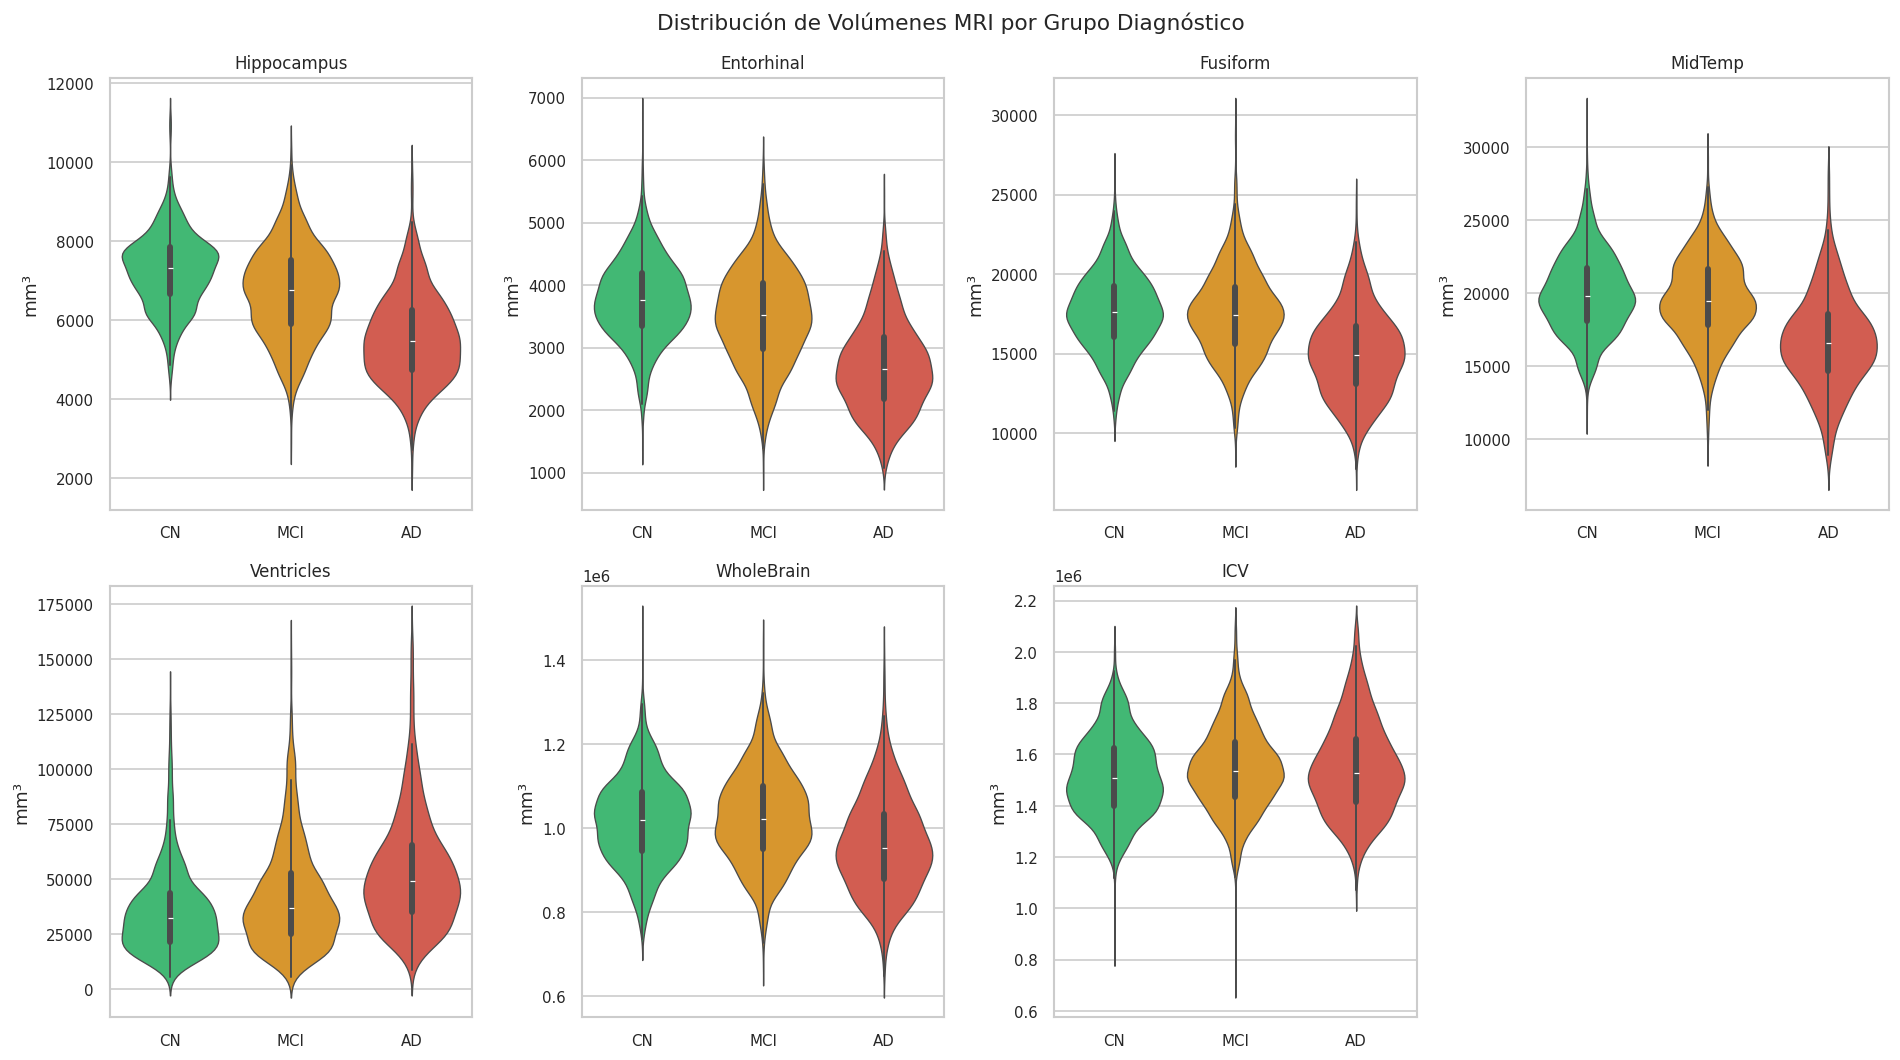

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(COLS_MRI):
    ax = axes[i]
    sns.violinplot(data=df_dx, x='DX3', y=col, order=DX_ORDER,
                   palette=DX_PALETTE, ax=ax, inner='box',
                   linewidth=0.8, density_norm='width')
    ax.set_xlabel('')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('mm³')

# Ocultar el subplot sobrante
axes[-1].set_visible(False)

plt.suptitle('Distribución de Volúmenes MRI por Grupo Diagnóstico', fontsize=13)
plt.tight_layout()
plt.show()

Los volúmenes MRI muestran el patrón de **atrofia progresiva** esperado en la enfermedad de Alzheimer.

**Hippocampus** y **Entorhinal** son los mejores discriminadores: el hipocampo pasa de concentrarse en ~7.500 mm³ en CN a ~5.500 mm³ en AD, reflejo de la atrofia temprana en las regiones de memoria. 

**Ventricles** presenta el patrón inverso — aumenta en AD porque al perder tejido cerebral los ventrículos se expanden para ocupar el espacio, siendo también un buen indicador de neurodegeneración. 

**Fusiform**, **MidTemp** y **WholeBrain** muestran separación más moderada con mayor solapamiento entre grupos, lo que los hace menos discriminativos individualmente.

**ICV** (volumen intracraneal, determinado por el cráneo) tiene distribuciones prácticamente idénticas en los tres grupos — comportamiento esperado y que valida la consistencia del dato, ya que ICV no se ve afectado por la enfermedad y se usa principalmente como covariable de normalización para el resto de volúmenes.

####  2.3.3 - PET Y CSF

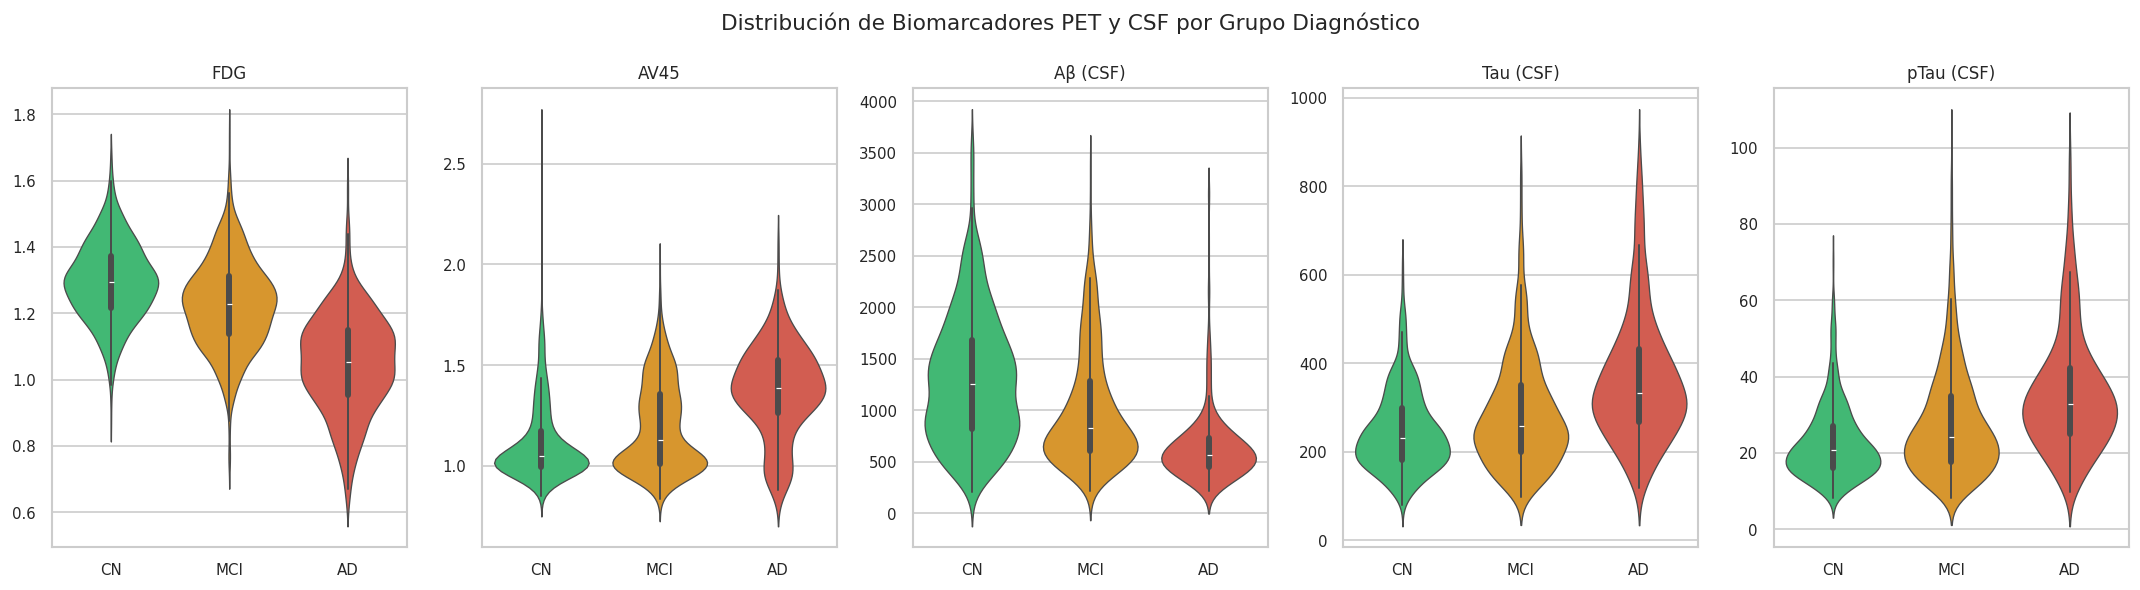

In [23]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

pet_csf = COLS_PET + COLS_CSF
labels  = ['FDG', 'AV45', 'Aβ (CSF)', 'Tau (CSF)', 'pTau (CSF)']

for i, (col, label) in enumerate(zip(pet_csf, labels)):
    ax = axes[i]
    sns.violinplot(data=df_dx, x='DX3', y=col, order=DX_ORDER,
                   palette=DX_PALETTE, ax=ax, inner='box',
                   linewidth=0.8, density_norm='width')
    ax.set_xlabel('')
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('')

plt.suptitle('Distribución de Biomarcadores PET y CSF por Grupo Diagnóstico', fontsize=13)
plt.tight_layout()
plt.show()

Los biomarcadores PET y CSF ilustran perfectamente el **marco A/T/N del Alzheimer**. 

**FDG-PET** (metabolismo glucídico) decrece de CN a AD — los cerebros con Alzheimer presentan hipometabolismo progresivo — aunque CN y MCI muestran distribuciones muy similares, lo que limita su utilidad para detección temprana. 

**AV45-PET** (carga amiloide) sigue el patrón inverso: aumenta de CN a AD, y destaca que MCI ya muestra valores elevados solapándose con AD, lo que refleja que la acumulación de amiloide comienza años antes de que aparezcan síntomas clínicos. 

En CSF, **Aβ disminuye** de CN a AD porque el amiloide queda atrapado en las placas cerebrales y desaparece del líquido cefalorraquídeo, mientras que **Tau y pTau aumentan** como marcadores de daño neuronal activo. Las distribuciones CSF muestran alta variabilidad inter-individual (colas largas), lo que sugiere que serán variables útiles pero con mayor ruido que los tests cognitivos o el hipocampo.

###  2.4 - MATRIZ DE CORRELACIONES

####  2.4.1 - CORRELACIÓN INTRA-GRUPO

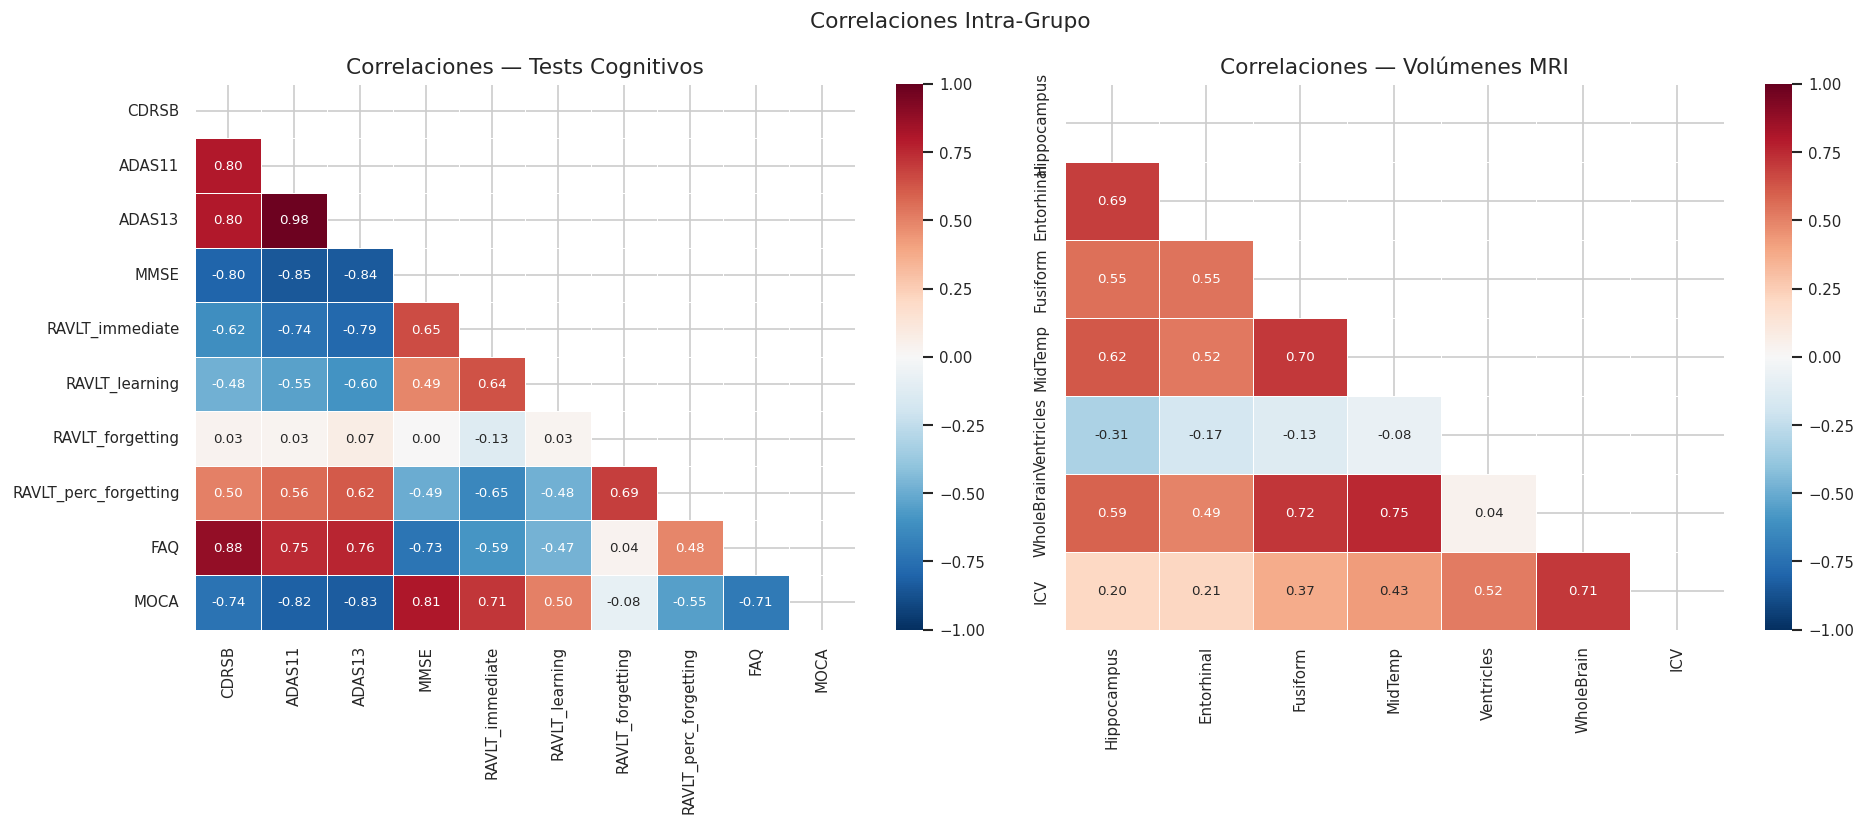

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Cognitivos
cols_cog_valid = [c for c in COLS_COG if c in df.columns]
corr_cog = df[cols_cog_valid].corr()
mask_cog = np.triu(np.ones_like(corr_cog, dtype=bool))
sns.heatmap(corr_cog, mask=mask_cog, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], linewidths=0.5, annot_kws={'size': 8})
axes[0].set_title('Correlaciones — Tests Cognitivos')

# MRI
cols_mri_valid = [c for c in COLS_MRI if c in df.columns]
corr_mri = df[cols_mri_valid].corr()
mask_mri = np.triu(np.ones_like(corr_mri, dtype=bool))
sns.heatmap(corr_mri, mask=mask_mri, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[1], linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('Correlaciones — Volúmenes MRI')

plt.suptitle('Correlaciones Intra-Grupo', fontsize=13)
plt.tight_layout()
plt.show()

####  2.4.2 - CORRELACIÓN ENTRE GRUPOS

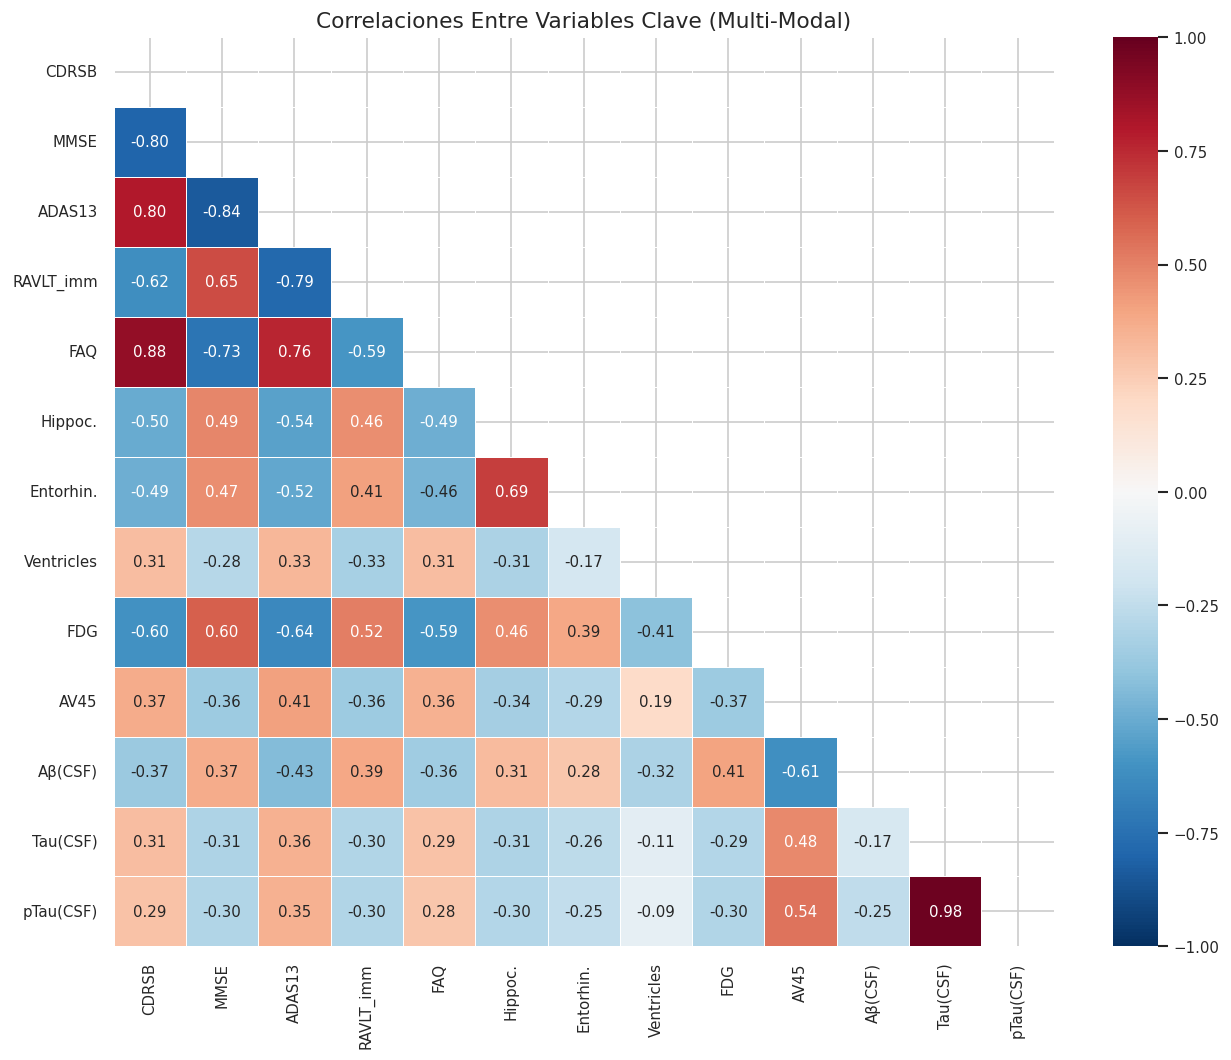

In [29]:
# Seleccionar las variables más representativas de cada grupo
cols_key = ['CDRSB', 'MMSE', 'ADAS13', 'RAVLT_immediate', 'FAQ',
            'Hippocampus', 'Entorhinal', 'Ventricles',
            'FDG', 'AV45',
            'ABETA_UPENNBIOMK9_04_19_17',
            'TAU_UPENNBIOMK9_04_19_17',
            'PTAU_UPENNBIOMK9_04_19_17']

cols_key = [c for c in cols_key if c in df.columns]
labels_key = ['CDRSB','MMSE','ADAS13','RAVLT_imm','FAQ',
              'Hippoc.','Entorhin.','Ventricles',
              'FDG','AV45','Aβ(CSF)','Tau(CSF)','pTau(CSF)']

corr_key = df[cols_key].corr()
mask_key = np.triu(np.ones_like(corr_key, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_key, mask=mask_key, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=labels_key, yticklabels=labels_key,
            ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlaciones Entre Variables Clave (Multi-Modal)', fontsize=13)
plt.tight_layout()
plt.show()

####  2.4.3 - CORRELACIÓN CON LA VARIABLE OBJETIVO (DX3)

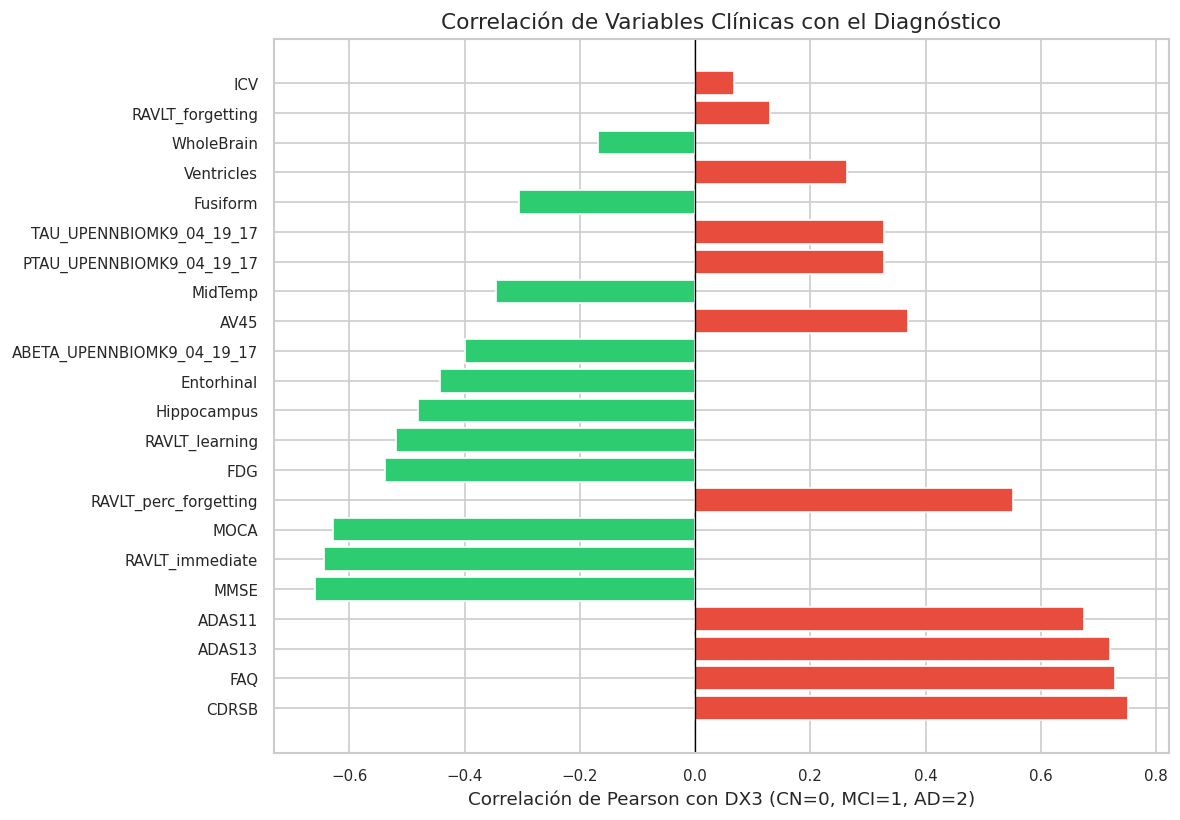


Top 10 variables más correlacionadas con el diagnóstico:
CDRSB                    0.751
FAQ                      0.728
ADAS13                   0.720
ADAS11                   0.675
MMSE                    -0.660
RAVLT_immediate         -0.644
MOCA                    -0.628
RAVLT_perc_forgetting    0.552
FDG                     -0.539
RAVLT_learning          -0.519


In [30]:
# Codificar DX3 como numérico: CN=0, MCI=1, AD=2
dx3_num = df['DX3'].map({'CN': 0, 'MCI': 1, 'AD': 2})

cols_all = [c for c in COLS_COG + COLS_MRI + COLS_PET + COLS_CSF if c in df.columns]
corr_target = (df[cols_all]
               .corrwith(dx3_num)
               .dropna()
               .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con DX3 (CN=0, MCI=1, AD=2)')
ax.set_title('Correlación de Variables Clínicas con el Diagnóstico')
plt.tight_layout()
plt.show()

print("\nTop 10 variables más correlacionadas con el diagnóstico:")
print(corr_target.head(10).round(3).to_string())

####  2.4.4 - CORRELACIÓN GLOBAL

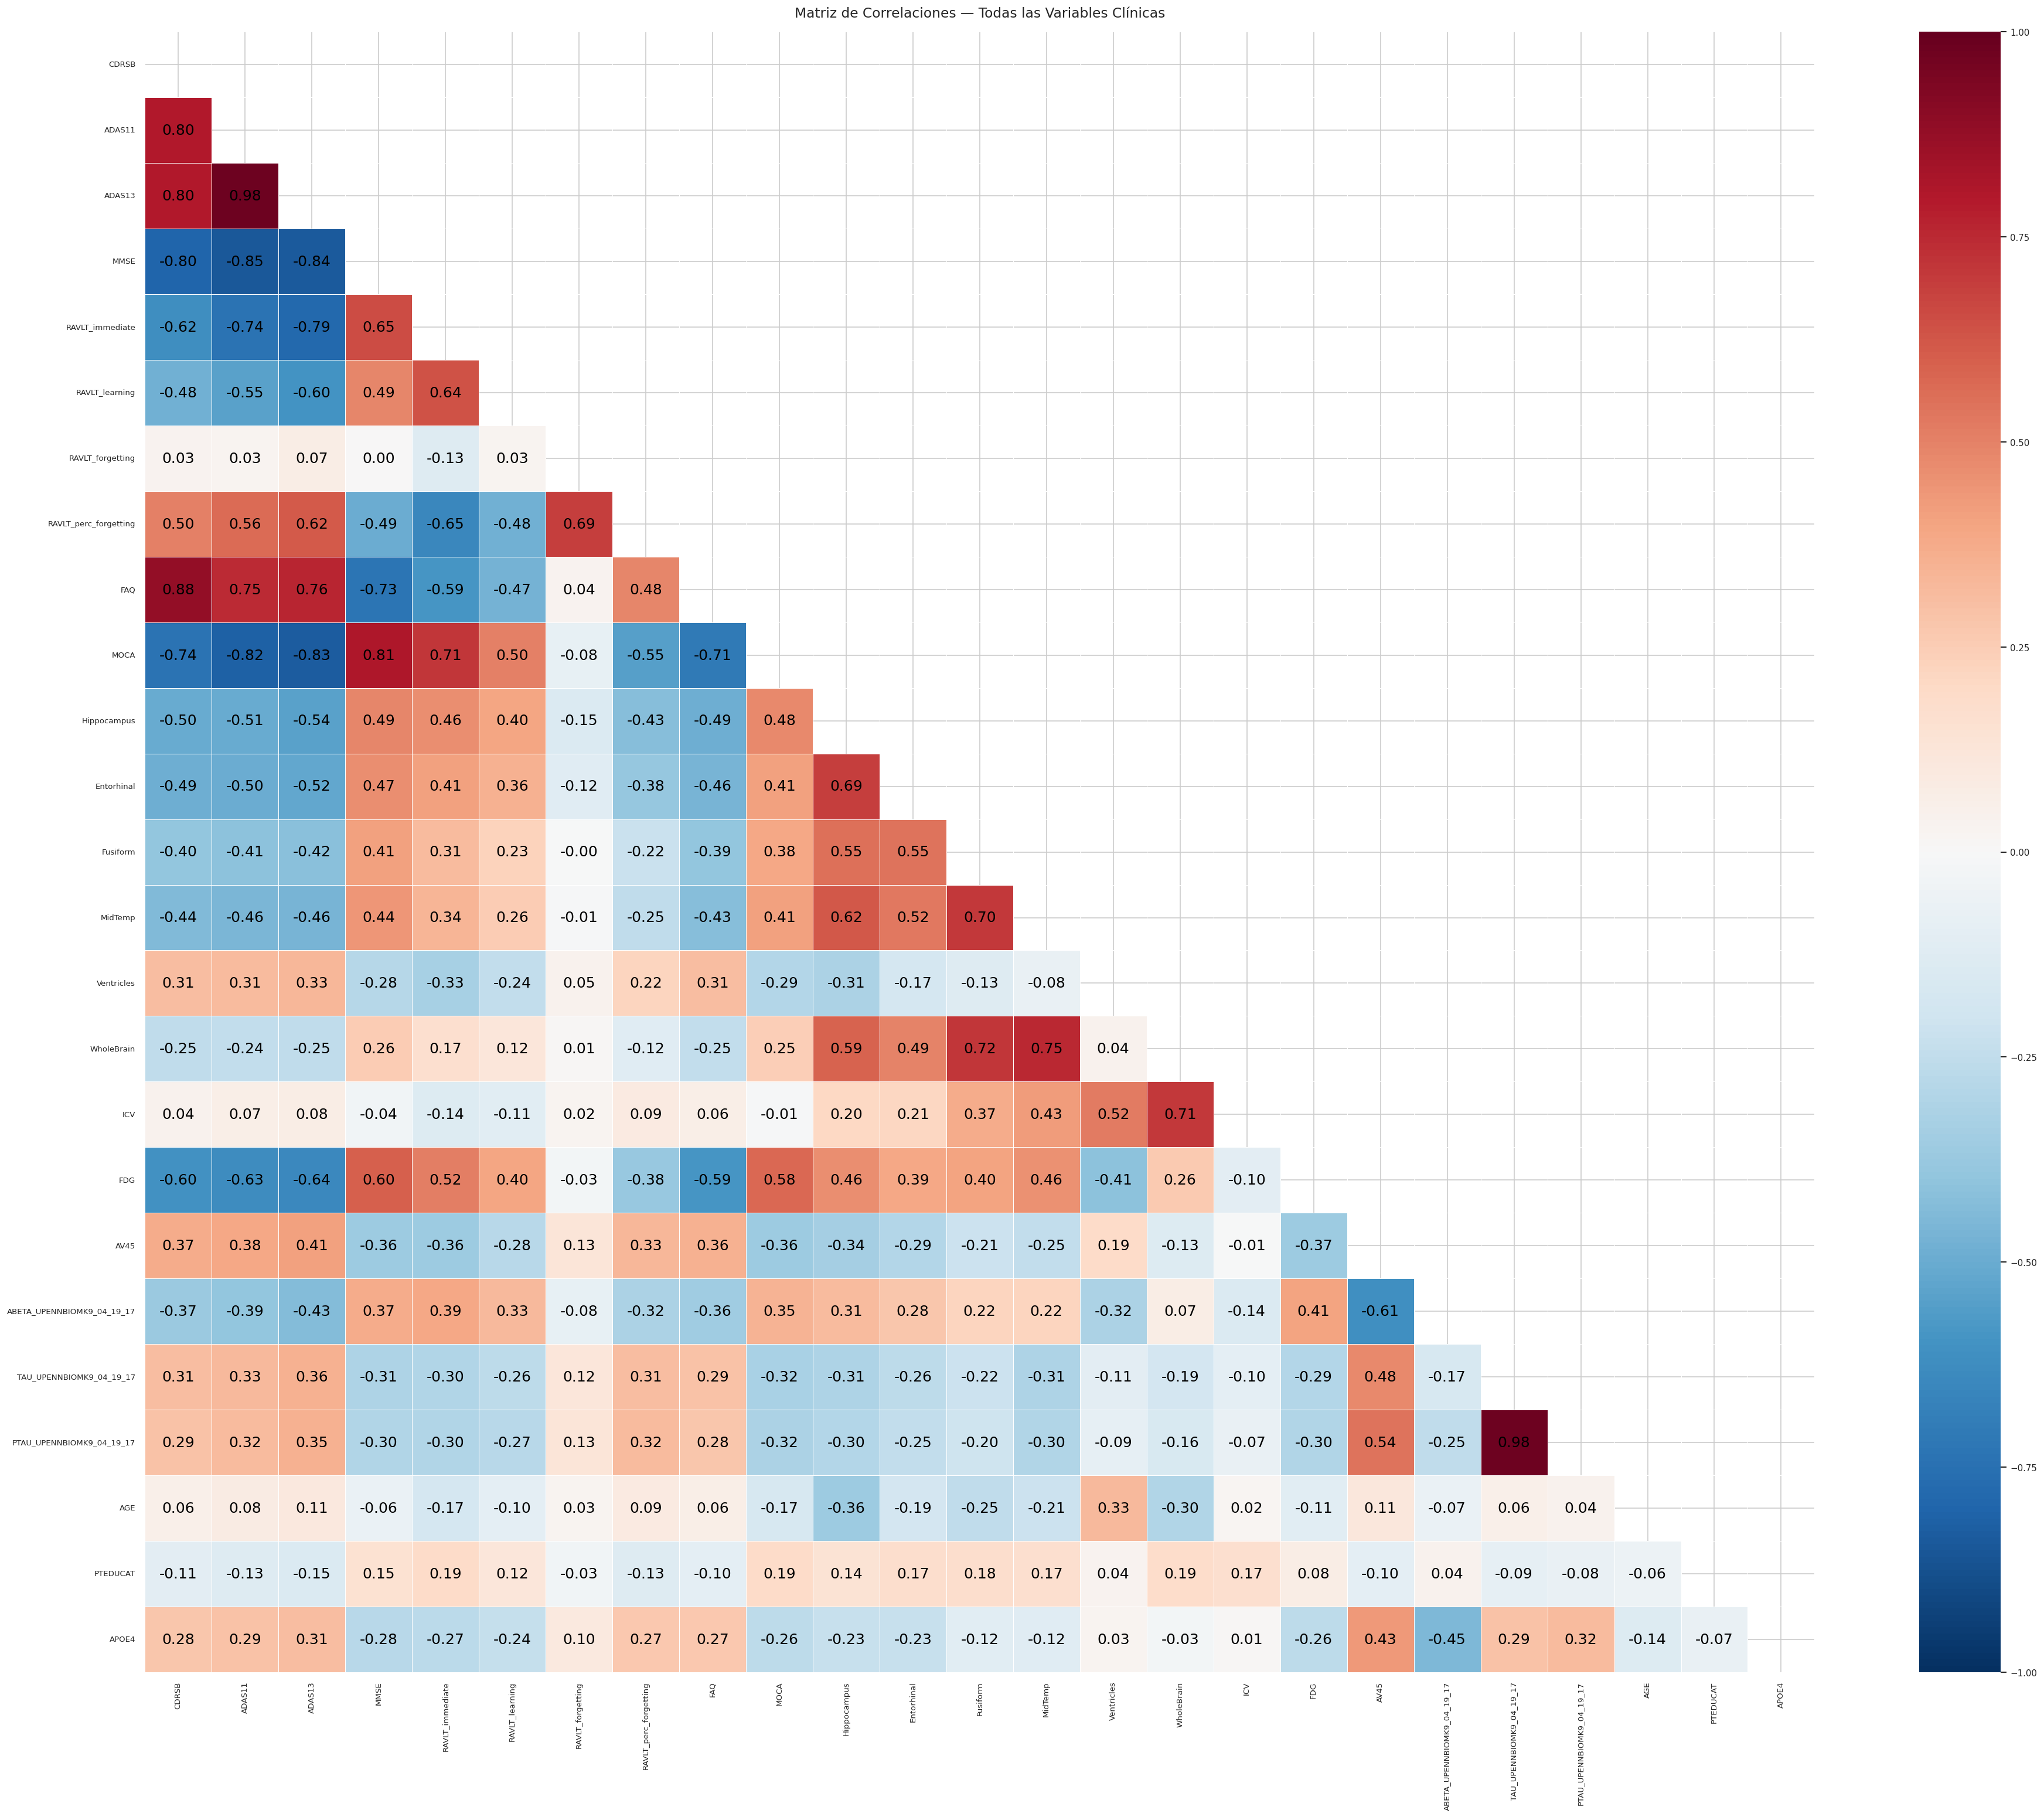

In [39]:
cols_all = [c for c in COLS_COG + COLS_MRI + COLS_PET + COLS_CSF + COLS_DEMO
            if c in df.columns and df[c].dtype in ['float64','int64']]

corr_all = df[cols_all].corr()
mask = np.triu(np.ones_like(corr_all, dtype=bool))

fig, ax = plt.subplots(figsize=(32, 26))
sns.heatmap(corr_all, mask=mask,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='white',
            annot=True, fmt='.2f', annot_kws={'size': 15, 'color': 'black'},
            ax=ax)
ax.set_title('Matriz de Correlaciones — Todas las Variables Clínicas', fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()